<h3>Imports</h3>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso

from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline


### df1

In [2]:
Base_Dir = os.getcwd()
path = rf'{Base_Dir}\IEEE_Victoris2_Filtration_train_data'
data_files = [f for f in os.listdir(path) if f.endswith('.csv')]
files = [os.path.join(path, data_files[i]) for i in range (len(data_files))]

In [3]:
def read_data(file):
    data = pd.read_csv(file, index_col=0)
    return data

In [4]:
train_1 , train_2, train_3 = [read_data(files[i]) for i in range(len(files))]

In [5]:
train_1.head(2)

,Person Description,Place Code,Customer Order,Additional Features in market,Promotion Name,Store Kind,Store Sales,Store Cost,Product Weights Data in (KG),Is Recyclable?,Min. Yearly Income,Store Area,Grocery Area,Frozen Area,Meat Area,Cost
mc_ID_0,"Single Female with four children, education: b...",H11go_ZA,"Cleaning Supplies from Household department, O...","['Video Store', 'Florist', 'Ready Food', 'Coff...",Dimes Off,Deluxe,8.76 Millions,4.2924 Millions,"{'Gross Weight': 28.1997, 'Net Weight': 26.600...",recyclable,10K+,2842.23,2037.64,481.98,323,602.7575
mc_ID_1,"Single Female with three children, education: ...",S04ne_WA,"Snack Foods from Snack Foods department, Order...",NaN,Budget Bargains,Supermarket,6.36 Millions,1.9716 Millions,"{'Gross Weight': 16.571, 'Net Weight': 14.972,...",non recyclable,50K+,2814.95,2049.72,457.36,NaN,708.6650


In [6]:
train_1.isna().sum()*100/train_1.shape[0]

Person Description                0.000000
Place Code                        0.000000
Customer Order                    0.000000
Additional Features in market    22.119342
Promotion Name                   14.969136
Store Kind                       14.969136
Store Sales                       0.000000
Store Cost                        0.000000
Product Weights Data in (KG)      0.000000
Is Recyclable?                    0.000000
Min. Yearly Income                0.015432
Store Area                       10.066872
Grocery Area                     10.185185
Frozen Area                       9.948560
Meat Area                        10.020576
Cost                              0.123457
dtype: float64

In [7]:
train_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19440 entries, mc_ID_0 to mc_ID_19354
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Person Description             19440 non-null  object 
 1   Place Code                     19440 non-null  object 
 2   Customer Order                 19440 non-null  object 
 3   Additional Features in market  15140 non-null  object 
 4   Promotion Name                 16530 non-null  object 
 5   Store Kind                     16530 non-null  object 
 6   Store Sales                    19440 non-null  object 
 7   Store Cost                     19440 non-null  object 
 8   Product Weights Data in (KG)   19440 non-null  object 
 9   Is Recyclable?                 19440 non-null  object 
 10  Min. Yearly Income             19437 non-null  object 
 11  Store Area                     17483 non-null  object 
 12  Grocery Area                   17460 no

In [8]:
per_desc = train_1['Person Description'].str.split(' ').str
train_1['Person'], train_1['Gender'], train_1['Children'] = per_desc[0], per_desc[1], per_desc[3]

In [9]:
import ast
train_1['Net Weight'] = train_1['Product Weights Data in (KG)'].apply(lambda x: ast.literal_eval(x)['Net Weight'])

In [10]:
selected_cols = ['Person', 'Gender', 'Children', 'Customer Order', 'Promotion Name', 'Store Kind', 'Store Sales', 'Store Cost', 'Net Weight', 'Cost']

In [11]:
train_1 = train_1[selected_cols]

In [12]:
train_1.head(2)

,Person,Gender,Children,Customer Order,Promotion Name,Store Kind,Store Sales,Store Cost,Net Weight,Cost
mc_ID_0,Single,Female,four,"Cleaning Supplies from Household department, O...",Dimes Off,Deluxe,8.76 Millions,4.2924 Millions,26.6008,602.7575
mc_ID_1,Single,Female,three,"Snack Foods from Snack Foods department, Order...",Budget Bargains,Supermarket,6.36 Millions,1.9716 Millions,14.9720,708.6650


In [13]:
renamed_cols = ['person', 'gender', 'children', 'customer_order', 'promotion_name', 'store_kind', 'store_sales', 'store_cost', 'net_weight', 'cost']

In [14]:
train_1 = train_1.rename(columns=dict(zip(selected_cols, renamed_cols)))

In [15]:
train_1 = train_1.dropna()

In [16]:
train_1.head(2)

,person,gender,children,customer_order,promotion_name,store_kind,store_sales,store_cost,net_weight,cost
mc_ID_0,Single,Female,four,"Cleaning Supplies from Household department, O...",Dimes Off,Deluxe,8.76 Millions,4.2924 Millions,26.6008,602.7575
mc_ID_1,Single,Female,three,"Snack Foods from Snack Foods department, Order...",Budget Bargains,Supermarket,6.36 Millions,1.9716 Millions,14.9720,708.6650


### df2

In [17]:
per_desc = train_2['Person Description'].str.split(' ').str
train_2['Person'], train_2['Gender'], train_2['children'] = per_desc[0], per_desc[1], per_desc[3]
train_2.head(2)

,Person Description,Place Code,Customer Order,Additional Features in market,Promotion Name,Store Kind,Store Sales,Store Cost,Gross Weight,Net Weight,Is Recyclable?,Min. Person Yearly Income,Store Area,Grocery Area,Frozen Area,Meat Area,Cost,Person,Gender,children
mc_ID_0,"Single Male with two children, education: high...",S01em_OR,"Baking Goods from Baking Goods department, Ord...","['Video Store', 'Florist', 'Ready Food', 'Bar ...",Tip Top Savings,Deluxe,3.28 M,0.984 M,21.9493,19.0421,yes,30K+,2577.50,1734.50,503.07,335.38,287.1270,Single,Male,two
mc_ID_1,"Married Male with four children, education: hi...",T02ma_WA,"Canned Sardines from Canned Foods department, ...","['Florist', 'Bar For Salad', 'Ready Food', 'Co...",Discount Frenzy,Deluxe,9.35 M,4.2075 M,19.1874,16.1349,yes,30K+,3145.51,2057.74,654.13,NaN,779.6884,Married,Male,four


In [18]:
train_2 = train_2.drop(['Person Description'],axis=1)

In [19]:
train_2 = train_2.rename(columns=dict(zip(selected_cols, renamed_cols)))

In [20]:
train_2 = train_2[renamed_cols]

In [21]:
train_2 = train_2.dropna()

In [22]:
train_2.head(2)

,person,gender,children,customer_order,promotion_name,store_kind,store_sales,store_cost,net_weight,cost
mc_ID_0,Single,Male,two,"Baking Goods from Baking Goods department, Ord...",Tip Top Savings,Deluxe,3.28 M,0.984 M,19.0421,287.1270
mc_ID_1,Married,Male,four,"Canned Sardines from Canned Foods department, ...",Discount Frenzy,Deluxe,9.35 M,4.2075 M,16.1349,779.6884


### df3

In [23]:
per_desc = train_3['Person%20Description'].str.split(' ').str
train_3['Person'], train_3['Gender'], train_3['children'] = per_desc[0], per_desc[1], per_desc[3]
train_3.head(2)

,Person%20Description,Place%20Code,Customer%20Order,Additional%20Features%20in%20market,Promotion%20Name,Store%20Kind,Store%20Sales,Store%20Cost,Gross%20Weight,Net%20Weight,...,Is%20Recyclable?,Yearly%20Income,Store%20Area,Grocery%20Area,Frozen%20Area,Meat%20Area,Cost,Person,Gender,children
mc_ID_0,"Single Female with two children, education: pa...",T02ma_WA,"Meat from Deli department, Ordered Brand : Red...","['Coffee Bar', 'Florist', 'Ready Food', 'Bar F...",Sale : Double Down,Deluxe,7.12 Millions,2.5632 Millions,23.2575,20.3503,...,yes,90K+,3145.51,2056.79,654.13,436.09,500.7202,Single,Female,two
mc_ID_1,"Single Female with five children, education: p...",M10da_YU,"Specialty from Produce department, Ordered Bra...","['Coffee Bar', 'Florist', 'Bar For Salad', 'Vi...",GLD,Deluxe,14.72 Millions,7.0656 Millions,16.7163,12.3555,...,yes,30K+,2856.68,1871.16,595.93,395.51,484.1411,Single,Female,five


In [24]:
train_3 = train_3.drop(['Person%20Description'],axis=1)

In [25]:
selected_cols = ['Person', 'Gender', 'children', 'Customer%20Order', 'Promotion%20Name', 'Store%20Kind', 'Store%20Sales', 'Store%20Cost', 'Net%20Weight','Cost']

In [26]:
train_3 = train_3.rename(columns=dict(zip(selected_cols, renamed_cols)))

In [27]:
train_3 = train_3[renamed_cols]

In [28]:
train_3 = train_3.dropna()

In [29]:
train_3.head(2)

,person,gender,children,customer_order,promotion_name,store_kind,store_sales,store_cost,net_weight,cost
mc_ID_0,Single,Female,two,"Meat from Deli department, Ordered Brand : Red...",Sale : Double Down,Deluxe,7.12 Millions,2.5632 Millions,20.3503,500.7202
mc_ID_1,Single,Female,five,"Specialty from Produce department, Ordered Bra...",GLD,Deluxe,14.72 Millions,7.0656 Millions,12.3555,484.1411


### final df

In [30]:
final_df = pd.concat([train_1, train_2, train_3])

In [31]:
encoder = LabelEncoder()

In [32]:
final_df.head(2)

,person,gender,children,customer_order,promotion_name,store_kind,store_sales,store_cost,net_weight,cost
mc_ID_0,Single,Female,four,"Cleaning Supplies from Household department, O...",Dimes Off,Deluxe,8.76 Millions,4.2924 Millions,26.6008,602.7575
mc_ID_1,Single,Female,three,"Snack Foods from Snack Foods department, Order...",Budget Bargains,Supermarket,6.36 Millions,1.9716 Millions,14.9720,708.6650


In [33]:
final_df['customer_order'] = encoder.fit_transform(final_df['customer_order'])
final_df['store_kind'] = encoder.fit_transform(final_df['store_kind'])
final_df = pd.get_dummies(final_df, columns=['promotion_name'], drop_first=True)

In [34]:
final_df['store_cost'] = final_df['store_cost'].str.split(' ').str[0].astype(float)
final_df['store_sales'] = final_df['store_sales'].str.split(' ').str[0].astype(float)
final_df['children'] = final_df['children'].map({'No':0, 'one':1, 'two':2, 'three':3, 'four':4, 'five':5})
final_df['gender'] = final_df['gender'].map({'Male':1,'Female':0})
final_df['person'] = final_df['person'].map({'Single':1,'Married':2})

In [35]:
final_df.dtypes

person                                       int64
gender                                       int64
children                                     int64
customer_order                               int64
store_kind                                   int64
store_sales                                float64
store_cost                                 float64
net_weight                                 float64
cost                                       float64
promotion_name_Best Price Savers              bool
promotion_name_Best Savings                   bool
promotion_name_Big Time Discounts             bool
promotion_name_Big Time Saving                bool
promotion_name_Budget Bargains                bool
promotion_name_Coupon Spectacular             bool
promotion_name_Dimes Off                      bool
promotion_name_Discount Frenzy                bool
promotion_name_Dollar Days                    bool
promotion_name_Double Your Savings            bool
promotion_name_Fantastic Discou

In [36]:
final_df.head(2)

,person,gender,children,customer_order,store_kind,store_sales,store_cost,net_weight,cost,promotion_name_Best Price Savers,...,promotion_name_Super Duper Savers,promotion_name_Super Savers,promotion_name_Super Wallet Savers,promotion_name_Three for One,promotion_name_Tip Top Savings,promotion_name_Two Day Sale,promotion_name_Two for One,promotion_name_Wallet Savers,promotion_name_Weekend Discount,promotion_name_You Save Days
mc_ID_0,1,0,4,88,0,8.76,4.2924,26.6008,602.7575,False,...,False,False,False,False,False,False,False,False,False,False
mc_ID_1,1,0,3,239,4,6.36,1.9716,14.9720,708.6650,False,...,False,False,False,False,False,False,False,False,False,False


### Building model

In [37]:
X = final_df.drop('cost', axis=1).values
y = final_df['cost'].values

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=1, stratify=y)

In [39]:
final_df.isna().sum()

person                                     0
gender                                     0
children                                   0
customer_order                             0
store_kind                                 0
store_sales                                0
store_cost                                 0
net_weight                                 0
cost                                       0
promotion_name_Best Price Savers           0
promotion_name_Best Savings                0
promotion_name_Big Time Discounts          0
promotion_name_Big Time Saving             0
promotion_name_Budget Bargains             0
promotion_name_Coupon Spectacular          0
promotion_name_Dimes Off                   0
promotion_name_Discount Frenzy             0
promotion_name_Dollar Days                 0
promotion_name_Double Your Savings         0
promotion_name_Fantastic Discounts         0
promotion_name_Full Free                   0
promotion_name_GLD                         0
promotion_

In [40]:
knn = make_pipeline(StandardScaler(), KNeighborsRegressor())
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
knn_score = root_mean_squared_error(y_test,y_pred)
knn_score

130.98696614801216

In [41]:
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.1,random_state=1))
lasso.fit(X_train,y_train)
y_pred = lasso.predict(X_test)
lasso_score = root_mean_squared_error(y_test,y_pred)
lasso_score

133.8052801276142

In [42]:
regression = make_pipeline(StandardScaler(), LinearRegression())
regression.fit(X_train, y_train)
y_pred = regression.predict(X_test)
regression_score = root_mean_squared_error(y_test,y_pred)
regression_score

133.81889704503635

In [43]:
svr = make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2))
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)
svr_score = root_mean_squared_error(y_test,y_pred)
svr_score

138.57125343761157

In [44]:
rf = make_pipeline(StandardScaler(), RandomForestRegressor())
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rfr_score = root_mean_squared_error(y_test,y_pred)
rfr_score

112.60094494674802

In [45]:
params = {'n_estimators':[100,200], 'max_depth':[20,25,30]}
rfr =  RandomForestRegressor()
grid = GridSearchCV(rfr, param_grid=params, cv=5)
grid.fit(X_train, y_train)
best_rf = make_pipeline(StandardScaler(), RandomForestRegressor(**grid.best_params_))
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)
best_rfr_score = root_mean_squared_error(y_test,y_pred)

In [46]:
scores = f"""
__________________________________
                       KNN Loss: {knn_score:0.2f}
                     Lasso Loss: {lasso_score:0.2f}
         Linear Regression Loss: {regression_score:0.2f}
                       SVR Loss: {svr_score:0.2f}
             Random Forest Loss: {rfr_score:0.2f}
Random Forest With GridSearchCV: {best_rfr_score:0.2f}
__________________________________
"""

print(scores)



__________________________________
                       KNN Loss: 130.99
                     Lasso Loss: 133.81
         Linear Regression Loss: 133.82
                       SVR Loss: 138.57
             Random Forest Loss: 112.60
Random Forest With GridSearchCV: 113.67
__________________________________



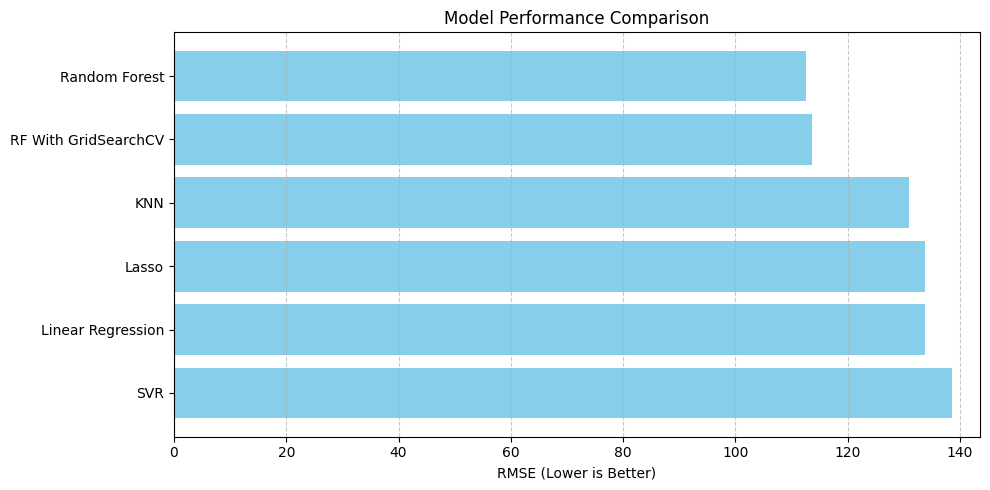

In [47]:
models = ['KNN', 'Lasso', 'Linear Regression', 'SVR', 'Random Forest', 'RF With GridSearchCV']
scores = [knn_score, lasso_score, regression_score, svr_score, rfr_score, best_rfr_score]

score_df = pd.DataFrame({'Model':models, 'RMSE':scores})
score_df_sorted = score_df.sort_values(by='RMSE', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(score_df_sorted['Model'], score_df_sorted['RMSE'], color='skyblue')
plt.xlabel('RMSE (Lower is Better)')
plt.title('Model Performance Comparison')
plt.xlim(0, max(scores) + 5)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()


In [48]:
best_model_name = models[np.argmin(scores)]
print(f"Best Model: {best_model_name} with RMSE: {min(scores):0.2f}")

Best Model: Random Forest with RMSE: 112.60


In [49]:
final_df.to_csv(rf'{Base_Dir}\final_dataframe.csv', index=False)

In [50]:
models_objs = [knn, lasso, regression, svr, rf, best_rf]
models_dict = dict(zip(models, models_objs))
best_model = models_dict[best_model_name]

In [51]:
test_data = read_data(rf'{Base_Dir}\test.csv')
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19942 entries, 0 to 19941
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Person Description             19942 non-null  object 
 1   Place Code                     19942 non-null  object 
 2   Customer Order                 19942 non-null  object 
 3   Additional Features in market  19942 non-null  object 
 4   Promotion Name                 19916 non-null  object 
 5   Store Kind                     19914 non-null  object 
 6   Store Sales                    19942 non-null  object 
 7   Store Cost                     19942 non-null  object 
 8   Gross Weight                   18959 non-null  float64
 9   Net Weight                     18924 non-null  float64
 10  Package Weight                 19942 non-null  float64
 11  Is Recyclable?                 19942 non-null  object 
 12  Yearly Income                  19942 non-null  obje

In [52]:
test_data.isna().sum()

Person Description                  0
Place Code                          0
Customer Order                      0
Additional Features in market       0
Promotion Name                     26
Store Kind                         28
Store Sales                         0
Store Cost                          0
Gross Weight                      983
Net Weight                       1018
Package Weight                      0
Is Recyclable?                      0
Yearly Income                       0
Store Area                        996
Grocery Area                     1042
Frozen Area                       961
Meat Area                         975
dtype: int64

In [53]:
test_data.head(2)

,Person Description,Place Code,Customer Order,Additional Features in market,Promotion Name,Store Kind,Store Sales,Store Cost,Gross Weight,Net Weight,Package Weight,Is Recyclable?,Yearly Income,Store Area,Grocery Area,Frozen Area,Meat Area
0,"Single Male with four children, education: par...",B06ls_CA,"Candy from Snacks department, Ordered Brand : ...","['Florist', 'Ready Food', 'Video Store', 'Bar ...",Fantastic Discounts,Gourmet,11.76 Millions,4.704 Millions,31.8337,28.7811,3.0525,yes,50K+,2201.06,1424.85,465.54,308.73
1,"Married Female with three children, education:...",S01em_OR,"Vegetables from Frozen Foods department, Order...","['Florist', 'Coffee Bar', 'Ready Food', 'Bar F...",Bag Stuffer,Deluxe,2.16 Millions,0.6696 Millions,29.9440,27.0368,2.9072,no,70K+,2577.16,1735.17,505.07,336.59


In [54]:
per_desc = test_data['Person Description'].str.split(' ').str
test_data['Person'], test_data['Gender'], test_data['children'] = per_desc[0], per_desc[1], per_desc[3]
test_data.head(2)

,Person Description,Place Code,Customer Order,Additional Features in market,Promotion Name,Store Kind,Store Sales,Store Cost,Gross Weight,Net Weight,Package Weight,Is Recyclable?,Yearly Income,Store Area,Grocery Area,Frozen Area,Meat Area,Person,Gender,children
0,"Single Male with four children, education: par...",B06ls_CA,"Candy from Snacks department, Ordered Brand : ...","['Florist', 'Ready Food', 'Video Store', 'Bar ...",Fantastic Discounts,Gourmet,11.76 Millions,4.704 Millions,31.8337,28.7811,3.0525,yes,50K+,2201.06,1424.85,465.54,308.73,Single,Male,four
1,"Married Female with three children, education:...",S01em_OR,"Vegetables from Frozen Foods department, Order...","['Florist', 'Coffee Bar', 'Ready Food', 'Bar F...",Bag Stuffer,Deluxe,2.16 Millions,0.6696 Millions,29.9440,27.0368,2.9072,no,70K+,2577.16,1735.17,505.07,336.59,Married,Female,three


In [55]:
test_data = test_data.drop(['Person Description'],axis=1)

In [56]:
selected_cols = ['Person', 'Gender', 'Children', 'Customer Order', 'Promotion Name', 'Store Kind', 'Store Sales', 'Store Cost', 'Net Weight', 'Cost']
test_data = test_data.rename(columns=dict(zip(selected_cols, renamed_cols)))

In [57]:
test_data = test_data[renamed_cols[:-1]]

In [58]:
na_cols = test_data.columns[test_data.isna().sum()>0]
for col in na_cols:
    if test_data[col].dtype == 'object':
        test_data[col].fillna(test_data[col].mode()[0], inplace=True)
    else:
        test_data[col].fillna(test_data[col].mean(), inplace=True)

C:\Users\a1mme\AppData\Local\Temp\ipykernel_20536\3550158964.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data[col].fillna(test_data[col].mode()[0], inplace=True)
C:\Users\a1mme\AppData\Local\Temp\ipykernel_20536\3550158964.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [59]:
test_data.isna().sum()

person            0
gender            0
children          0
customer_order    0
promotion_name    0
store_kind        0
store_sales       0
store_cost        0
net_weight        0
dtype: int64

In [60]:
test_data.head(2)

,person,gender,children,customer_order,promotion_name,store_kind,store_sales,store_cost,net_weight
0,Single,Male,four,"Candy from Snacks department, Ordered Brand : ...",Fantastic Discounts,Gourmet,11.76 Millions,4.704 Millions,28.7811
1,Married,Female,three,"Vegetables from Frozen Foods department, Order...",Bag Stuffer,Deluxe,2.16 Millions,0.6696 Millions,27.0368


In [61]:
encoder_2 = LabelEncoder()
test_data['customer_order'] = encoder_2.fit_transform(test_data['customer_order'])
test_data['store_kind'] = encoder_2.fit_transform(test_data['store_kind'])
test_data = pd.get_dummies(test_data, columns=['promotion_name'], drop_first=True)

In [62]:
test_data['store_cost'] = test_data['store_cost'].str.split(' ').str[0].astype(float)
test_data['store_sales'] = test_data['store_sales'].str.split(' ').str[0].astype(float)
test_data['children'] = test_data['children'].map({'No':0, 'one':1, 'two':2, 'three':3, 'four':4, 'five':5})
test_data['gender'] = test_data['gender'].map({'Male':1,'Female':0})
test_data['person'] = test_data['person'].map({'Single':1,'Married':2})

In [63]:
test_data.dtypes

person                                       int64
gender                                       int64
children                                     int64
customer_order                               int64
store_kind                                   int64
store_sales                                float64
store_cost                                 float64
net_weight                                 float64
promotion_name_Best Price Savers              bool
promotion_name_Best Savings                   bool
promotion_name_Big Time Discounts             bool
promotion_name_Big Time Saving                bool
promotion_name_Budget Bargains                bool
promotion_name_Coupon Spectacular             bool
promotion_name_Dimes Off                      bool
promotion_name_Discount Frenzy                bool
promotion_name_Dollar Days                    bool
promotion_name_Double Your Savings            bool
promotion_name_Fantastic Discounts            bool
promotion_name_Full Free       

In [64]:
test_data.head(2)

,person,gender,children,customer_order,store_kind,store_sales,store_cost,net_weight,promotion_name_Best Price Savers,promotion_name_Best Savings,...,promotion_name_Super Duper Savers,promotion_name_Super Savers,promotion_name_Super Wallet Savers,promotion_name_Three for One,promotion_name_Tip Top Savings,promotion_name_Two Day Sale,promotion_name_Two for One,promotion_name_Wallet Savers,promotion_name_Weekend Discount,promotion_name_You Save Days
0,1,1,4,42,1,11.76,4.7040,28.7811,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,0,3,263,0,2.16,0.6696,27.0368,False,False,...,False,False,False,False,False,False,False,False,False,False


In [65]:
X = test_data.values
predictions = best_model.predict(X)
id_list = np.arange(1, len(predictions)+1)

In [66]:
submission_df = pd.DataFrame({'ID':id_list, 'Cost':predictions})
submission_df.head(2)

,ID,Cost
0,1,718.915800
1,2,506.081996


In [67]:
submission_df.to_csv('final.csv', index=False)